# 1. Análisis Exploratorio y Preprocesamiento

En este notebook se realizaran las siguientes tareas:
1. Cargar y visualizar ejemplos de ambas clases
2. Analizar distribución de clases y tamaño de imágenes
3. Implementar pipeline de preprocesamiento:
    + Normalización de tamaño
    + Ecualización de histograma (CLAHE para radiografías)
4. Se creará un nuevo dataset preprocesado

## 1.1 Importar librerías

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from collections import Counter
from tqdm import tqdm
import shutil


In [ ]:
#Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.2 Cargar dataset y configurar rutas

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
# Ruta base del dataset descomprimido

DATASET_PATH = "/kaggle/input/chest-xray-pneumonia/chest_xray"

#imágenes de entrenamiento
train_normal = glob(os.path.join(DATASET_PATH, "train/NORMAL/*.jpeg"))
train_pneu   = glob(os.path.join(DATASET_PATH, "train/PNEUMONIA/*.jpeg"))



In [ ]:
#Ruta de salida

OUTPUT_PATH = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/Clasificación de Imágenes Médicas/results/chest_xray_preprocessed"

# Crear carpeta raíz
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

# Crear carpetas espejo al dataset original
subsets = ["train", "test", "val"]
classes = ["NORMAL", "PNEUMONIA"]

for subset in subsets:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_PATH, subset, cls), exist_ok=True)

## 1.3 Análisis exploratorio

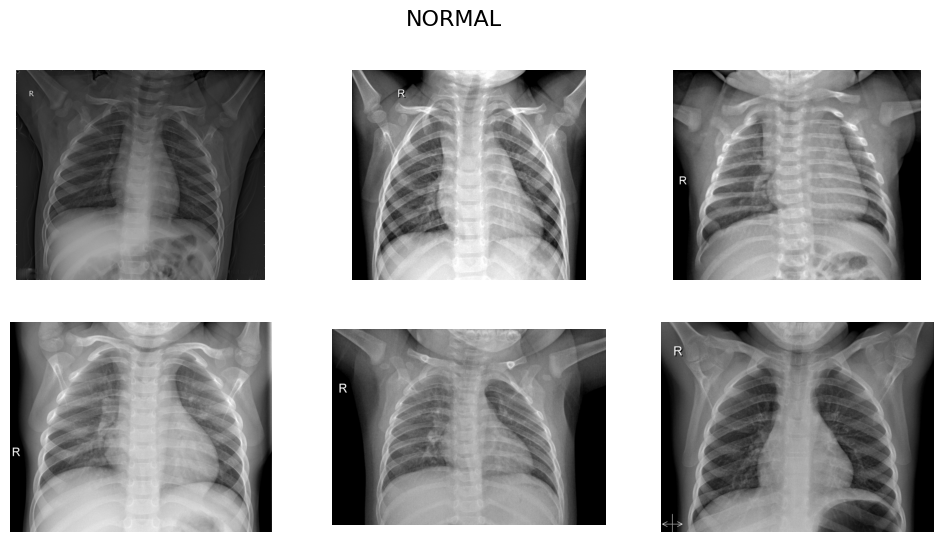

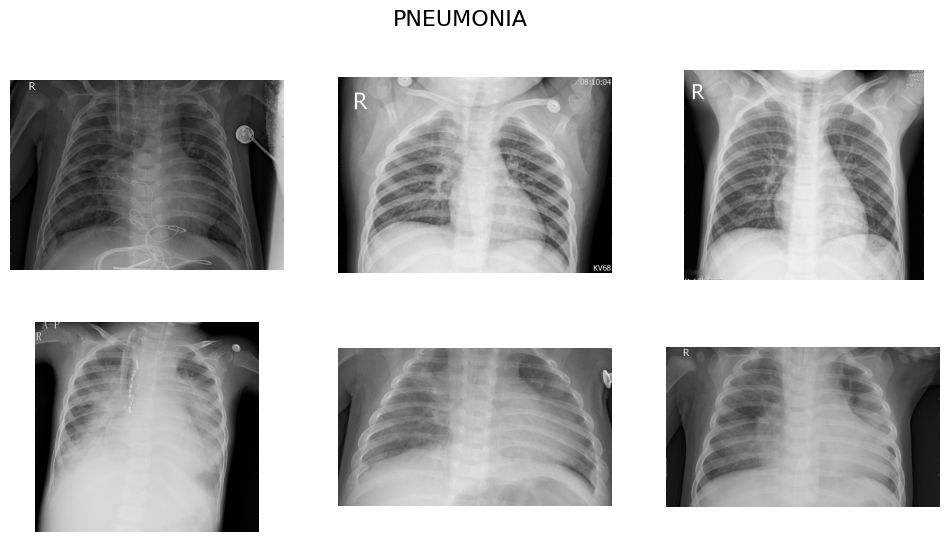

In [ ]:
# Se Visualizan imágenes de ambas clases

#Se definine una función que permite, leer las imágenes y visualizarlas
def show_samples(paths, title, n=6):
    plt.figure(figsize=(12,6))
    for i, img_path in enumerate(paths[:n]):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(2, n//2, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.show()

show_samples(train_normal, "NORMAL")
show_samples(train_pneu, "PNEUMONIA")

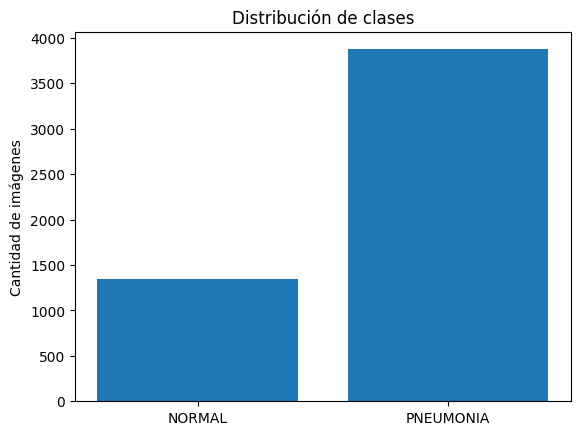

In [ ]:
#Se realiza un histograma pra visualizar la distribución de clases en train
labels = ['NORMAL'] * len(train_normal) + ['PNEUMONIA'] * len(train_pneu)
Counter(labels)

plt.bar(['NORMAL', 'PNEUMONIA'], [len(train_normal), len(train_pneu)])
plt.title("Distribución de clases")
plt.ylabel("Cantidad de imágenes")
plt.show()

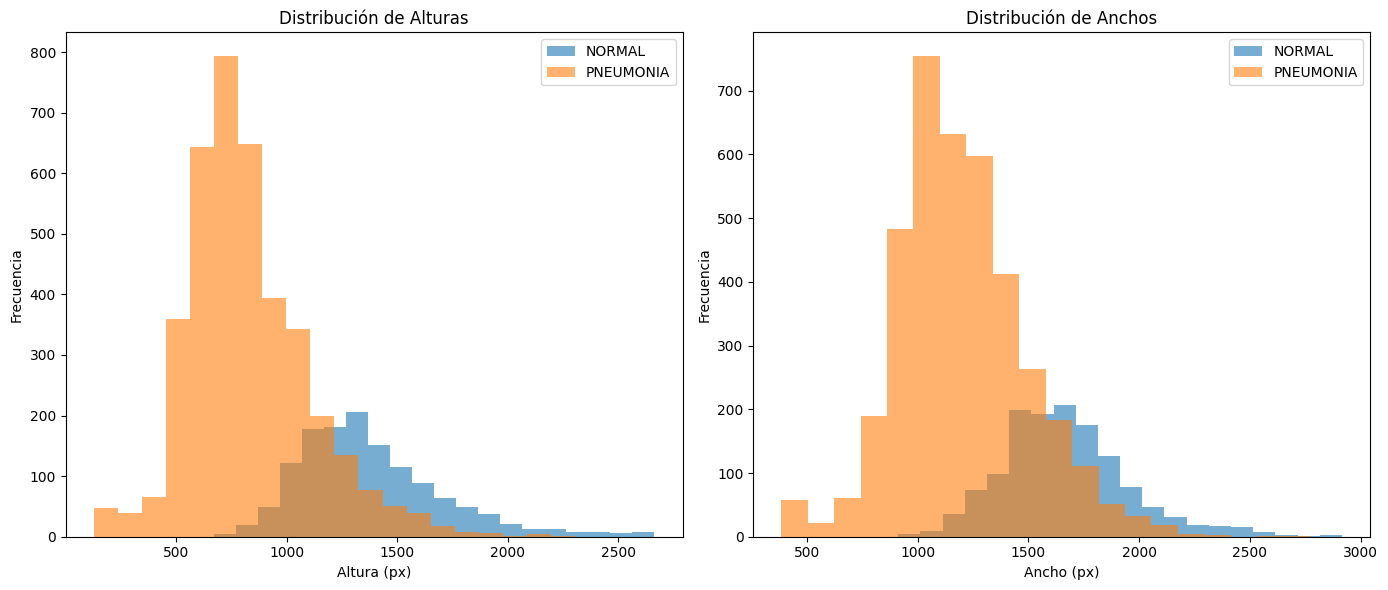

In [ ]:
#Se define una función para analizar los tamaños de los imágenes
def extract_sizes(paths):
    heights, widths = [], []
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        h, w = img.shape
        heights.append(h)
        widths.append(w)
    return heights, widths

# Extraer tamaños
h_norm, w_norm = extract_sizes(train_normal)
h_pneu, w_pneu = extract_sizes(train_pneu)

# Graficar
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.hist(h_norm, bins=20, alpha=0.6, label='NORMAL')
plt.hist(h_pneu, bins=20, alpha=0.6, label='PNEUMONIA')
plt.title("Distribución de Alturas")
plt.xlabel("Altura (px)")
plt.ylabel("Frecuencia")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(w_norm, bins=20, alpha=0.6, label='NORMAL')
plt.hist(w_pneu, bins=20, alpha=0.6, label='PNEUMONIA')
plt.title("Distribución de Anchos")
plt.xlabel("Ancho (px)")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()


##1.4 Preprocesamiento

In [ ]:
# 1. Se define la función para reescalar la imagen 256x256
def resize_image(img, size=256):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)


    # 2.Se define la función para la ecualización adaptativa de histograma con límite de contraste CLAHE, con valores usuales en RX
    #límite de contraste 2 y grilla de 8x8
def apply_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(img)





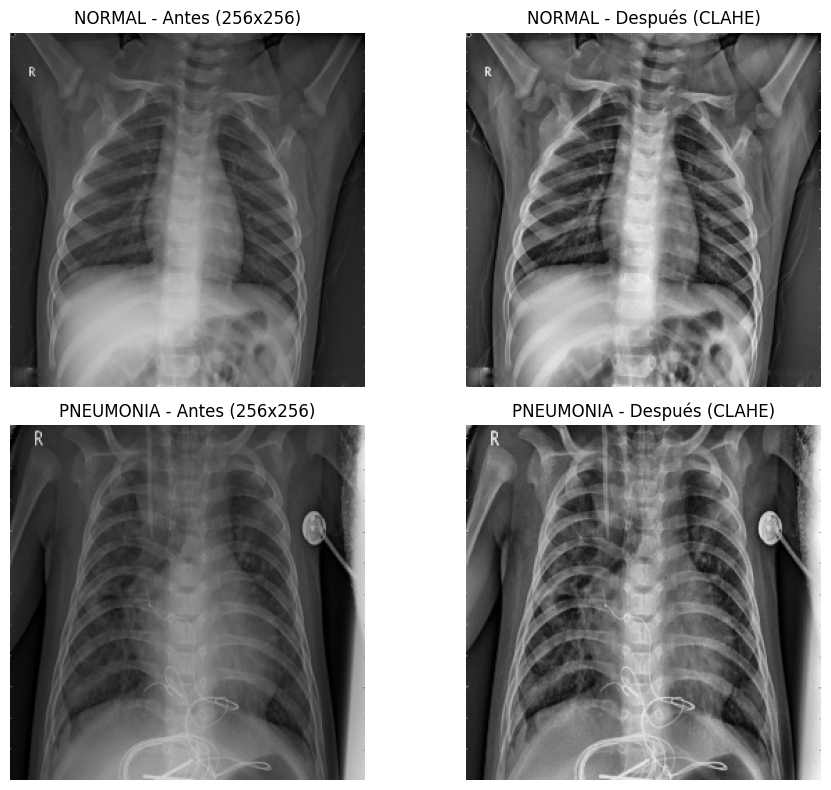

In [ ]:
#Se elige una imagen de cada clase para visualizar el CLAHE
normal_sample_path = cv2.imread(train_normal[0], cv2.IMREAD_GRAYSCALE)
pneu_sample_path   = cv2.imread(train_pneu[0], cv2.IMREAD_GRAYSCALE)

# Preprocesar
norm_resized=resize_image(normal_sample_path)
norm_clahe = apply_clahe(norm_resized)
pneu_resized=resize_image(pneu_sample_path)
pneu_clahe = apply_clahe(pneu_resized)

plt.figure(figsize=(10,8))

# Fila 1: NORMAL
plt.subplot(2, 2, 1)
plt.imshow(norm_resized, cmap='gray')
plt.title("NORMAL - Antes (256x256)")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(norm_clahe, cmap='gray')
plt.title("NORMAL - Después (CLAHE)")
plt.axis('off')

# Fila 2: PNEUMONIA
plt.subplot(2, 2, 3)
plt.imshow(pneu_resized, cmap='gray')
plt.title("PNEUMONIA - Antes (256x256)")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(pneu_clahe, cmap='gray')
plt.title("PNEUMONIA - Después (CLAHE)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Se define la función para preprocesar y guardar todo el dataset

def preprocess_and_save(input_folder, output_folder):
    images = os.listdir(input_folder)

    for img_name in tqdm(images, desc=f"Procesando {input_folder}"):
        img_path = os.path.join(input_folder, img_name)

        # Leer en escala de grises
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # 1) Resize
        img = resize_image(img, 256)

        # 2) CLAHE
        img = apply_clahe(img)

        # 3) Segmentación
        #img = simple_lung_segmentation(img)

        # Guardar
        out_path = os.path.join(output_folder, img_name)
        cv2.imwrite(out_path, img)



In [ ]:
#Se recorren todas las carpetsd del dataset
for subset in subsets:
    for cls in classes:
        input_path = os.path.join(DATASET_PATH, subset, cls)
        output_path = os.path.join(OUTPUT_PATH, subset, cls)

        preprocess_and_save(input_path, output_path)

Procesando /kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL: 100%|██████████| 1341/1341 [00:52<00:00, 25.63it/s]
Procesando /kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA: 100%|██████████| 3875/3875 [01:29<00:00, 43.21it/s]
Procesando /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL: 100%|██████████| 234/234 [00:08<00:00, 28.68it/s]
Procesando /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA: 100%|██████████| 390/390 [00:08<00:00, 44.60it/s]
Procesando /kaggle/input/chest-xray-pneumonia/chest_xray/val/NORMAL: 100%|██████████| 8/8 [00:00<00:00, 25.20it/s]
Procesando /kaggle/input/chest-xray-pneumonia/chest_xray/val/PNEUMONIA: 100%|██████████| 8/8 [00:00<00:00, 40.98it/s]
